# Лабораторная работа 2 (часть 2)

**ФИО:** Богатырев Никита Андреевич  
**Группа:** ЕТ-215

## Тема
Прикладные задачи на данных интернет-магазина

## Инструменты
- Python
- NumPy
- Pandas
- Matplotlib
- Jupyter Notebook

## Описание работы
В ноутбуке последовательно выполняются все этапы анализа данных интернет-магазина:
формирование набора из 3000 заказов, проверка качества данных, подготовка
производных признаков (выручка, прибыль, возрастные группы), фильтрация,
группировка, визуализация и мини-анализ с выводами.

Данные генерируются искусственно с фиксированным seed (`numpy.random.seed(2024)`),
поэтому результаты полностью воспроизводимы при каждом запуске ноутбука сверху вниз.

## Часть 0. Подготовка данных

### 0.1. Настройки и справочники

Фиксируем seed генератора случайных чисел, чтобы данные были одинаковыми при
каждом запуске. Города, категории товаров, статусы и способы оплаты задаются
списками, как в задании. Названия товаров сформированы самостоятельно — по 6
товаров в каждой категории (всего 30 позиций).

Для каждой категории задан свой диапазон цены: у электроники цены заметно выше,
чем у остальных категорий, что позволит получить неравномерное распределение
выручки между категориями.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(2024)

# Единый стиль графиков для всего ноутбука
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

n_orders = 3000        # количество заказов
n_customers = 800      # количество уникальных клиентов (диапазон id)
n_missing_age = 30     # сколько пропусков добавим в возраст

cities = ["Москва", "Санкт-Петербург", "Казань", "Екатеринбург", "Челябинск"]
categories = ["Электроника", "Одежда", "Дом", "Красота", "Спорт"]
statuses = ["Доставлен", "Отменён", "Возврат"]
payments = ["Карта", "Онлайн", "Наличные"]

# Названия товаров по категориям
products = {
    "Электроника": ["Смартфон", "Ноутбук", "Планшет", "Наушники", "Телевизор", "Смарт-часы"],
    "Одежда": ["Куртка", "Джинсы", "Кроссовки", "Футболка", "Платье", "Свитер"],
    "Дом": ["Пылесос", "Чайник", "Микроволновка", "Подушка", "Кастрюля", "Постельное бельё"],
    "Красота": ["Шампунь", "Крем для лица", "Помада", "Духи", "Бритва", "Косметичка"],
    "Спорт": ["Коврик для фитнеса", "Гантели", "Скейтборд", "Кроссовки для бега", "Шлем", "Эспандер"],
}

# Диапазоны цен (минимум, максимум) для каждой категории
price_range = {
    "Электроника": (2000, 30000),
    "Одежда": (700, 15000),
    "Дом": (500, 16000),
    "Красота": (300, 8000),
    "Спорт": (400, 14000),
}

# Веса (вероятности) для категориальных признаков
city_p = [0.35, 0.20, 0.15, 0.15, 0.15]
category_p = [0.25, 0.25, 0.20, 0.15, 0.15]
status_p = [0.75, 0.15, 0.10]
payment_p = [0.60, 0.30, 0.10]

# Скидка выбирается из дискретного набора значений: чаще небольшая
discount_levels = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
discount_p = [0.30, 0.20, 0.15, 0.10, 0.10, 0.07, 0.04, 0.03, 0.01]

### 0.2. Генерация заказов

Каждый заказ — одна строка таблицы. Признаки генерируются независимо, кроме связки
«категория → товар»: сначала выбирается категория, затем товар из неё, а цена
подбирается равномерно из диапазона этой категории.

Особенности генерации:

* `quantity` — от 1 до 5, чаще встречаются заказы на 1–2 товара;
* `discount` — от 0 до 50 %, чаще 0–20 %;
* `cost` — себестоимость **одной единицы товара**: цена, умноженная на коэффициент
  от 0,45 до 1,0, то есть иногда себестоимость почти равна цене продажи;
* `order_date` — случайный день периода с 1 января по 31 декабря 2024 года
  (2024 год високосный, поэтому 366 дней);
* `is_vip` — 25 % заказов принадлежат VIP-клиентам.

После создания таблицы добавляем 30 пропущенных значений в столбец `age` и
сортируем заказы по дате, чтобы таблица выглядела как хронологический лог магазина.

In [2]:
# Идентификаторы и даты
order_id = np.arange(10001, 10001 + n_orders)
customer_id = np.random.choice(np.arange(1001, 1001 + n_customers), size=n_orders)
order_date = (
    pd.Timestamp("2024-01-01")
    + pd.to_timedelta(np.random.randint(0, 366, size=n_orders), unit="D")
)

# Клиент: город, возраст, признак VIP
city = np.random.choice(cities, size=n_orders, p=city_p)
age = np.clip(np.random.normal(40, 12, size=n_orders), 16, 85).astype(int)
is_vip = np.random.choice([True, False], size=n_orders, p=[0.25, 0.75])

# Товар: категория, название, цена
category = np.random.choice(categories, size=n_orders, p=category_p)
product_name = np.array([np.random.choice(products[c]) for c in category])
low = np.array([price_range[c][0] for c in category])
high = np.array([price_range[c][1] for c in category])
price = np.round(np.random.uniform(low, high), 2)

# Количество, скидка и себестоимость одной единицы товара
quantity = np.random.choice([1, 2, 3, 4, 5], size=n_orders,
                            p=[0.40, 0.25, 0.18, 0.10, 0.07])
discount = np.random.choice(discount_levels, size=n_orders, p=discount_p)
cost = np.round(price * np.random.uniform(0.45, 1.0, size=n_orders), 2)

# Статус заказа и способ оплаты
status = np.random.choice(statuses, size=n_orders, p=status_p)
payment = np.random.choice(payments, size=n_orders, p=payment_p)

df = pd.DataFrame({
    "order_id": order_id,
    "order_date": order_date,
    "customer_id": customer_id,
    "city": city,
    "age": age,
    "is_vip": is_vip,
    "product_name": product_name,
    "category": category,
    "quantity": quantity,
    "price": price,
    "discount": discount,
    "cost": cost,
    "status": status,
    "payment": payment,
})

# Добавляем около 30 пропущенных значений в столбец age
missing_idx = np.random.choice(n_orders, size=n_missing_age, replace=False)
df.loc[missing_idx, "age"] = np.nan

# Сортируем заказы по дате
df = df.sort_values("order_date").reset_index(drop=True)

Результат — первые строки собранной таблицы:

In [3]:
df.head()

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment
0,11974,2024-01-01,1554,Москва,59.0,True,Кастрюля,Дом,5,675.71,0.00,516.88,Доставлен,Карта
1,11277,2024-01-01,1421,Москва,48.0,True,Свитер,Одежда,3,2669.30,0.00,1509.45,Доставлен,Онлайн
2,12946,2024-01-01,1628,Санкт-Петербург,45.0,False,Куртка,Одежда,2,1871.57,0.00,1157.51,Доставлен,Карта
3,11028,2024-01-01,1512,Санкт-Петербург,42.0,False,Эспандер,Спорт,3,1467.32,0.00,1421.52,Доставлен,Карта
4,12561,2024-01-01,1788,Челябинск,38.0,False,Микроволновка,Дом,1,519.41,0.15,497.88,Доставлен,Карта


## Часть 1. Первичный анализ данных

Проверим, что данные загрузились корректно: посмотрим размер таблицы и типы
данных, первые и последние строки, описательные статистики и количество пропусков.

In [4]:
print("Размер DataFrame (строки, столбцы):", df.shape)
df.info()

Размер DataFrame (строки, столбцы): (3000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      3000 non-null   int64         
 1   order_date    3000 non-null   datetime64[ns]
 2   customer_id   3000 non-null   int64         
 3   city          3000 non-null   object        
 4   age           2970 non-null   float64       
 5   is_vip        3000 non-null   bool          
 6   product_name  3000 non-null   object        
 7   category      3000 non-null   object        
 8   quantity      3000 non-null   int64         
 9   price         3000 non-null   float64       
 10  discount      3000 non-null   float64       
 11  cost          3000 non-null   float64       
 12  status        3000 non-null   object        
 13  payment       3000 non-null   object        
dtypes: bool(1), datetime64[ns](1), float64(4)

In [5]:
df.head()

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment
0,11974,2024-01-01,1554,Москва,59.0,True,Кастрюля,Дом,5,675.71,0.00,516.88,Доставлен,Карта
1,11277,2024-01-01,1421,Москва,48.0,True,Свитер,Одежда,3,2669.30,0.00,1509.45,Доставлен,Онлайн
2,12946,2024-01-01,1628,Санкт-Петербург,45.0,False,Куртка,Одежда,2,1871.57,0.00,1157.51,Доставлен,Карта
3,11028,2024-01-01,1512,Санкт-Петербург,42.0,False,Эспандер,Спорт,3,1467.32,0.00,1421.52,Доставлен,Карта
4,12561,2024-01-01,1788,Челябинск,38.0,False,Микроволновка,Дом,1,519.41,0.15,497.88,Доставлен,Карта


In [6]:
df.tail()

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment
2995,12548,2024-12-31,1340,Москва,25.0,True,Наушники,Электроника,1,14254.21,0.20,9828.48,Доставлен,Карта
2996,10258,2024-12-31,1726,Москва,56.0,False,Кроссовки,Одежда,3,8525.30,0.00,4251.07,Возврат,Карта
2997,11752,2024-12-31,1515,Москва,22.0,False,Ноутбук,Электроника,1,24018.62,0.15,13525.93,Отменён,Карта
2998,12654,2024-12-31,1448,Екатеринбург,24.0,True,Куртка,Одежда,1,12263.66,0.05,8715.52,Отменён,Карта
2999,10660,2024-12-31,1558,Москва,29.0,False,Свитер,Одежда,5,14224.64,0.20,7439.73,Отменён,Карта


In [7]:
# Описательные статистики по числовым столбцам
df.describe()

,order_id,order_date,customer_id,age,quantity,price,discount,cost
count,3000.000000,3000,3000.000000,2970.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,11500.500000,2024-07-03 13:53:16.800000,1403.058333,39.326936,2.169333,9113.764680,0.106317,6608.694303
min,10001.000000,2024-01-01 00:00:00,1001.000000,16.000000,1.000000,318.510000,0.000000,212.560000
25%,10750.750000,2024-04-02 00:00:00,1209.000000,31.000000,1.000000,4158.930000,0.000000,2848.615000
50%,11500.500000,2024-07-05 00:00:00,1410.000000,39.000000,2.000000,7675.340000,0.100000,5392.220000
75%,12250.250000,2024-10-02 06:00:00,1598.000000,47.000000,3.000000,12662.455000,0.150000,8949.007500
max,13000.000000,2024-12-31 00:00:00,1800.000000,75.000000,5.000000,29967.620000,0.500000,28868.300000
std,866.169729,NaN,228.857556,11.664583,1.251605,6483.195965,0.109567,5104.502748


В `describe()` попадают только числовые столбцы (`order_id`, `customer_id`, `age`,
`quantity`, `price`, `discount`, `cost`). Видно, что средняя цена (9 114 руб.)
заметно выше медианной (7 675 руб.) — это следствие того, что цены внутри одной
категории заданы равномерно, а сама категория выбирается случайно.
Обратите внимание на `count` в строке `age`: 2970 вместо 3000 — пропуски уже видны.

In [8]:
# Количество пропусков в каждом столбце
df.isna().sum()

order_id         0
order_date       0
customer_id      0
city             0
age             30
is_vip           0
product_name     0
category         0
quantity         0
price            0
discount         0
cost             0
status           0
payment          0
dtype: int64

### Ответы на вопросы

Получим все необходимые значения отдельным расчётом:

In [9]:
print("1. Строк и столбцов:", df.shape)
print("2. Столбцы с пропусками:", df.isna().sum()[df.isna().sum() > 0].index.tolist())
print("3. Пропусков в age:", df["age"].isna().sum())
print("4. Уникальных клиентов:", df["customer_id"].nunique())
print("5. Уникальных товаров:", df["product_name"].nunique())
print("6. Города:", df["city"].unique().tolist())
print("7. Категории:", df["category"].unique().tolist())
print("8. Способы оплаты:", df["payment"].unique().tolist())
print("   Заказов в среднем на клиента:", round(df.shape[0] / df["customer_id"].nunique(), 2))

1. Строк и столбцов: (3000, 14)
2. Столбцы с пропусками: ['age']
3. Пропусков в age: 30
4. Уникальных клиентов: 787
5. Уникальных товаров: 30
6. Города: ['Москва', 'Санкт-Петербург', 'Челябинск', 'Казань', 'Екатеринбург']
7. Категории: ['Дом', 'Одежда', 'Спорт', 'Красота', 'Электроника']
8. Способы оплаты: ['Карта', 'Онлайн', 'Наличные']
   Заказов в среднем на клиента: 3.81


**Ответы:**

1. **3000 строк и 14 столбцов.**
2. Пропуски есть только в столбце `age`.
3. **30 пропусков** в `age` — это ровно 1 % выборки.
4. **787 уникальных клиентов**, в среднем ≈ 3,8 заказа на клиента.
5. **30 уникальных товаров** (6 товаров × 5 категорий).
6. Города: **Москва, Санкт-Петербург, Казань, Екатеринбург, Челябинск**.
7. Категории: **Электроника, Одежда, Дом, Красота, Спорт**.
8. Способы оплаты: **Карта, Онлайн, Наличные**.

**Вывод:** структура данных соответствует заданию, критичных проблем (потерянных
столбцов, неверных типов) нет. Единственный дефект — пропуски в возрасте, их
устраним на этапе подготовки данных (часть 2.4).

## Часть 2. Подготовка данных

### 2.1. Работа с датой

Столбец `order_date` приводим к типу даты (`datetime64`) — иначе нельзя извлечь
год и месяц, а также сравнивать и фильтровать даты. Из него создаём два отдельных
столбца: `year` и `month`.

In [10]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month

df[["order_id", "order_date", "year", "month"]].head()

,order_id,order_date,year,month
0,11974,2024-01-01,2024,1
1,11277,2024-01-01,2024,1
2,12946,2024-01-01,2024,1
3,11028,2024-01-01,2024,1
4,12561,2024-01-01,2024,1


### 2.2. Расчёт выручки и прибыли

* **Выручка (`revenue`)** — сумма, которую магазин получит от заказа с учётом
  количества товара и скидки: цена × количество × (1 − скидка).
* **Прибыль (`profit`)** — выручка за вычетом себестоимости.

In [11]:
df["revenue"] = df["price"] * df["quantity"] * (1 - df["discount"])
df["profit"] = df["revenue"] - df["cost"]

df[["order_id", "price", "quantity", "discount", "cost", "revenue", "profit"]].head()

,order_id,price,quantity,discount,cost,revenue,profit
0,11974,675.71,5,0.00,516.88,3378.5500,2861.6700
1,11277,2669.30,3,0.00,1509.45,8007.9000,6498.4500
2,12946,1871.57,2,0.00,1157.51,3743.1400,2585.6300
3,11028,1467.32,3,0.00,1421.52,4401.9600,2980.4400
4,12561,519.41,1,0.15,497.88,441.4985,-56.3815


Проверим, действительно ли часть заказов имеет отрицательную прибыль:

In [12]:
print("Всего заказов:", df.shape[0])
print("Заказов с отрицательной прибылью:", (df["profit"] < 0).sum())
print("Из них с количеством товара = 1:", ((df["profit"] < 0) & (df["quantity"] == 1)).sum())
print("Заказов с количеством товара = 1 всего:", (df["quantity"] == 1).sum())
print("Доля заказов с отрицательной прибылью:",
      round((df["profit"] < 0).mean() * 100, 1), "%")

# Примеры заказов с отрицательной прибылью
df.loc[df["profit"] < 0, ["price", "quantity", "discount", "revenue", "cost", "profit"]].head()

Всего заказов: 3000
Заказов с отрицательной прибылью: 240
Из них с количеством товара = 1: 240
Заказов с количеством товара = 1 всего: 1225
Доля заказов с отрицательной прибылью: 8.0 %


,price,quantity,discount,revenue,cost,profit
4,519.41,1,0.15,441.4985,497.88,-56.3815
7,27431.25,1,0.30,19201.8750,24284.54,-5082.6650
20,3266.06,1,0.15,2776.1510,3243.58,-467.4290
29,5069.78,1,0.15,4309.3130,4605.84,-296.5270
31,9831.14,1,0.10,8848.0260,8887.84,-39.8140


**Почему прибыль может быть отрицательной:**

1. **Разные единицы измерения.** `cost` — это себестоимость *одной единицы* товара,
   а `revenue` — сумма *за весь заказ*. Когда заказ содержит две и больше единицы,
   выручка почти всегда перекрывает себестоимость, поэтому вся отрицательная
   прибыль (240 заказов, 8 % выборки) приходится на заказы ровно из одной единицы
   (таких заказов 1225).
2. **Скидка.** Скидка уменьшает цену реализации, а себестоимость остаётся прежней.
3. **Себестоимость близка к цене.** Коэффициент себестоимости доходил до 1,0,
   поэтому при скидке 20–50 % выручка могла опуститься ниже себестоимости.
   Например, заказ № 10805 (Планшет, Санкт-Петербург): цена 29 790,68 руб.,
   скидка 40 %, себестоимость 27 248,03 руб. → выручка 17 874,41 руб.,
   прибыль −9 373,62 руб. Это самый убыточный заказ в выборке.

**Вывод:** отрицательная прибыль — не ошибка расчёта, а следствие того, что
себестоимость задана на единицу товара, а выручка считается на весь заказ,
и того, что потери от скидок ничем не компенсируются.

### 2.3. Реальная продажа

Создаём признак `is_real_sale` — доставлен ли заказ. Фактической выручкой
интернет-магазина считается выручка только по доставленным заказам.

In [13]:
df["is_real_sale"] = df["status"] == "Доставлен"

print("Количество заказов по статусам:")
print(df["status"].value_counts())
print()
print("Доля доставленных заказов:", round(df["is_real_sale"].mean() * 100, 1), "%")
print("Выручка по всем заказам, руб.:", round(df["revenue"].sum(), 2))
print("Выручка по доставленным заказам, руб.:", round(df.loc[df["is_real_sale"], "revenue"].sum(), 2))
print("Доля доставленных заказов в выручке, %:",
      round(df.loc[df["is_real_sale"], "revenue"].sum() / df["revenue"].sum() * 100, 1))

Количество заказов по статусам:
status
Доставлен    2239
Отменён       443
Возврат       318
Name: count, dtype: int64

Доля доставленных заказов: 74.6 %
Выручка по всем заказам, руб.: 53451788.56
Выручка по доставленным заказам, руб.: 39350490.37
Доля доставленных заказов в выручке, %: 73.6


**Ответ:** отменённый заказ не приносит магазину выручки (клиент не получил товар,
оплата не состоялась или была возвращена), а возвращённый — возвращает деньги
клиенту, при этом затраты на закупку, доставку и оформление уже понесены.
Если считать выручку по всем заказам, показатель был бы завышен: в наших данных
без учёта статуса выручка составляет 53,45 млн руб., а по факту реализовано
только 39,35 млн руб. (73,6 %), то есть 26,4 % «выручки» — фиктивная.

### 2.4. Пропуски в возрасте

Пропуски заполняем медианным возрастом: медиана устойчива к выбросам и не
смещает среднее значение, в отличие от среднего.

In [14]:
median_age = df["age"].median()
print("Медианный возраст:", median_age)

df["age"] = df["age"].fillna(median_age)

# Проверка: пропусков больше нет
print("Пропусков в age после заполнения:", df["age"].isna().sum())
print("Средний возраст после заполнения:", round(df["age"].mean(), 2))

Медианный возраст: 39.0
Пропусков в age после заполнения: 0
Средний возраст после заполнения: 39.32


**Вывод:** медианный возраст равен 39 годам, после заполнения пропусков в столбце
`age` не осталось ни одного `NaN`, а средний возраст (39,32) практически не
изменился — заполнение медианой не исказило распределение.

### 2.5. Возрастные группы

Функция `pd.cut()` разбивает числовой признак на интервалы и превращает его в
категориальный. Границы интервалов задаются в `bins`, а подписи — в `labels`.
По умолчанию интервалы закрыты справа: `(0, 18]`, `(18, 30]`, `(30, 45]`, `(45, 60]`,
`(60, 100]`.

In [15]:
bins = [0, 18, 30, 45, 60, 100]
labels = ["до 18", "18–30", "31–45", "46–60", "60+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

# reindex показывает все группы, даже если в какой-то из них нет заказов
age_group_orders = df["age_group"].value_counts().reindex(labels, fill_value=0)
age_group_orders

age_group
до 18     125
18–30     593
31–45    1387
46–60     787
60+       108
Name: count, dtype: int64

**Вывод:** основная масса заказов приходится на группу «31–45» — 1387 заказов
(46,2 %). Группы «до 18» (125 заказов) и «60+» (108 заказов) почти пусты, что
соответствует нормальному распределению возраста; 30 заказов с ранее
пропущенным возрастом попали в группу «31–45» вместе с медианой 39 лет.

## Часть 3. Фильтрация данных

Фильтрация в Pandas — это булева маска: условие даёт для каждой строки `True`
или `False`, а `df[маска]` возвращает только строки со значением `True`.
Ниже используются как одиночные условия, так и комбинации, соединённые
операторами `&` (логическое «И») и `|` (логическое «ИЛИ»).

### Простые фильтры

**Задание 1.** Заказы, где количество товаров больше 3.

In [16]:
qty_more_3 = df[df["quantity"] > 3]
print("Количество заказов:", qty_more_3.shape[0])
qty_more_3.head()

Количество заказов: 509


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
0,11974,2024-01-01,1554,Москва,59.0,True,Кастрюля,Дом,5,675.71,0.00,516.88,Доставлен,Карта,2024,1,3378.5500,2861.6700,True,46–60
5,11381,2024-01-01,1051,Челябинск,50.0,True,Куртка,Одежда,4,12168.63,0.50,11543.64,Отменён,Карта,2024,1,24337.2600,12793.6200,False,46–60
23,12626,2024-01-03,1333,Челябинск,47.0,False,Шампунь,Красота,4,4218.59,0.00,2247.58,Доставлен,Онлайн,2024,1,16874.3600,14626.7800,True,46–60
24,11727,2024-01-03,1389,Москва,46.0,False,Кроссовки,Одежда,5,9301.31,0.25,5793.48,Доставлен,Онлайн,2024,1,34879.9125,29086.4325,True,46–60
45,10893,2024-01-05,1295,Москва,16.0,True,Микроволновка,Дом,5,1268.30,0.20,915.92,Доставлен,Онлайн,2024,1,5073.2000,4157.2800,True,до 18


**Задание 2.** Заказы клиентов из Москвы.

In [17]:
moscow_orders = df[df["city"] == "Москва"]
print("Количество заказов:", moscow_orders.shape[0])
moscow_orders.head()

Количество заказов: 1080


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
0,11974,2024-01-01,1554,Москва,59.0,True,Кастрюля,Дом,5,675.71,0.0,516.88,Доставлен,Карта,2024,1,3378.550,2861.670,True,46–60
1,11277,2024-01-01,1421,Москва,48.0,True,Свитер,Одежда,3,2669.30,0.0,1509.45,Доставлен,Онлайн,2024,1,8007.900,6498.450,True,46–60
7,11311,2024-01-01,1035,Москва,59.0,False,Смарт-часы,Электроника,1,27431.25,0.3,24284.54,Доставлен,Онлайн,2024,1,19201.875,-5082.665,True,46–60
9,12720,2024-01-02,1227,Москва,45.0,True,Планшет,Электроника,3,6895.12,0.3,4169.31,Доставлен,Онлайн,2024,1,14479.752,10310.442,True,31–45
11,11076,2024-01-02,1355,Москва,41.0,True,Пылесос,Дом,1,3140.74,0.1,1768.92,Возврат,Наличные,2024,1,2826.666,1057.746,False,31–45


**Задание 3.** VIP-заказы.

In [18]:
vip_orders = df[df["is_vip"]]
print("Количество заказов:", vip_orders.shape[0])
vip_orders.head()

Количество заказов: 744


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
0,11974,2024-01-01,1554,Москва,59.0,True,Кастрюля,Дом,5,675.71,0.00,516.88,Доставлен,Карта,2024,1,3378.550,2861.670,True,46–60
1,11277,2024-01-01,1421,Москва,48.0,True,Свитер,Одежда,3,2669.30,0.00,1509.45,Доставлен,Онлайн,2024,1,8007.900,6498.450,True,46–60
5,11381,2024-01-01,1051,Челябинск,50.0,True,Куртка,Одежда,4,12168.63,0.50,11543.64,Отменён,Карта,2024,1,24337.260,12793.620,False,46–60
6,11043,2024-01-01,1464,Казань,65.0,True,Бритва,Красота,2,1740.28,0.00,1016.36,Возврат,Карта,2024,1,3480.560,2464.200,False,60+
8,10420,2024-01-01,1133,Казань,57.0,True,Гантели,Спорт,2,3940.09,0.05,3726.66,Отменён,Карта,2024,1,7486.171,3759.511,False,46–60


**Задание 4.** Заказы, где цена товара больше 5000 руб.

In [19]:
price_more_5000 = df[df["price"] > 5000]
print("Количество заказов:", price_more_5000.shape[0])
price_more_5000.head()

Количество заказов: 2063


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
5,11381,2024-01-01,1051,Челябинск,50.0,True,Куртка,Одежда,4,12168.63,0.50,11543.64,Отменён,Карта,2024,1,24337.260,12793.620,False,46–60
7,11311,2024-01-01,1035,Москва,59.0,False,Смарт-часы,Электроника,1,27431.25,0.30,24284.54,Доставлен,Онлайн,2024,1,19201.875,-5082.665,True,46–60
9,12720,2024-01-02,1227,Москва,45.0,True,Планшет,Электроника,3,6895.12,0.30,4169.31,Доставлен,Онлайн,2024,1,14479.752,10310.442,True,31–45
10,11053,2024-01-02,1025,Челябинск,16.0,True,Наушники,Электроника,2,8376.67,0.30,7063.95,Доставлен,Карта,2024,1,11727.338,4663.388,True,до 18
12,12422,2024-01-02,1540,Санкт-Петербург,35.0,False,Футболка,Одежда,1,14008.78,0.05,7929.58,Доставлен,Карта,2024,1,13308.341,5378.761,True,31–45


**Задание 5.** Заказы со скидкой больше 20 %.

In [20]:
discount_more_20 = df[df["discount"] > 0.20]
print("Количество заказов:", discount_more_20.shape[0])
discount_more_20.head()

Количество заказов: 434


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
5,11381,2024-01-01,1051,Челябинск,50.0,True,Куртка,Одежда,4,12168.63,0.50,11543.64,Отменён,Карта,2024,1,24337.2600,12793.6200,False,46–60
7,11311,2024-01-01,1035,Москва,59.0,False,Смарт-часы,Электроника,1,27431.25,0.30,24284.54,Доставлен,Онлайн,2024,1,19201.8750,-5082.6650,True,46–60
9,12720,2024-01-02,1227,Москва,45.0,True,Планшет,Электроника,3,6895.12,0.30,4169.31,Доставлен,Онлайн,2024,1,14479.7520,10310.4420,True,31–45
10,11053,2024-01-02,1025,Челябинск,16.0,True,Наушники,Электроника,2,8376.67,0.30,7063.95,Доставлен,Карта,2024,1,11727.3380,4663.3880,True,до 18
24,11727,2024-01-03,1389,Москва,46.0,False,Кроссовки,Одежда,5,9301.31,0.25,5793.48,Доставлен,Онлайн,2024,1,34879.9125,29086.4325,True,46–60


**Задание 6.** Количество заказов каждого статуса.

In [21]:
print("Количество заказов по статусам:")
print(df["status"].value_counts())
print()
print("Доли заказов по статутам, %:")
print((df["status"].value_counts(normalize=True) * 100).round(1))

Количество заказов по статусам:
status
Доставлен    2239
Отменён       443
Возврат       318
Name: count, dtype: int64

Доли заказов по статутам, %:
status
Доставлен    74.6
Отменён      14.8
Возврат      10.6
Name: proportion, dtype: float64


**Вывод:** больше 70 % заказов (2239 из 3000) имеют статус «Доставлен», на
отмены приходится 443 заказа (14,8 %), на возвраты — 318 заказов (10,6 %).
Значит, примерно каждый четвёртый заказ не приносит фактической выручки.

### Сложные фильтры

**Задание 7.** Заказы из Москвы с выручкой больше 5000 руб.

In [22]:
moscow_big_revenue = df[(df["city"] == "Москва") & (df["revenue"] > 5000)]
print("Количество заказов:", moscow_big_revenue.shape[0])
moscow_big_revenue.head()

Количество заказов: 868


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
1,11277,2024-01-01,1421,Москва,48.0,True,Свитер,Одежда,3,2669.30,0.00,1509.45,Доставлен,Онлайн,2024,1,8007.900,6498.450,True,46–60
7,11311,2024-01-01,1035,Москва,59.0,False,Смарт-часы,Электроника,1,27431.25,0.30,24284.54,Доставлен,Онлайн,2024,1,19201.875,-5082.665,True,46–60
9,12720,2024-01-02,1227,Москва,45.0,True,Планшет,Электроника,3,6895.12,0.30,4169.31,Доставлен,Онлайн,2024,1,14479.752,10310.442,True,31–45
18,11482,2024-01-03,1749,Москва,16.0,False,Наушники,Электроника,1,22171.30,0.15,17192.85,Доставлен,Онлайн,2024,1,18845.605,1652.755,True,до 18
19,11580,2024-01-03,1552,Москва,29.0,False,Коврик для фитнеса,Спорт,2,5429.66,0.00,3526.52,Отменён,Карта,2024,1,10859.320,7332.800,False,18–30


**Задание 8.** VIP-заказы категории «Электроника».

In [23]:
vip_electronics = df[(df["is_vip"]) & (df["category"] == "Электроника")]
print("Количество заказов:", vip_electronics.shape[0])
vip_electronics.head()

Количество заказов: 169


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
9,12720,2024-01-02,1227,Москва,45.0,True,Планшет,Электроника,3,6895.12,0.3,4169.31,Доставлен,Онлайн,2024,1,14479.752,10310.442,True,31–45
10,11053,2024-01-02,1025,Челябинск,16.0,True,Наушники,Электроника,2,8376.67,0.3,7063.95,Доставлен,Карта,2024,1,11727.338,4663.388,True,до 18
15,10111,2024-01-03,1066,Екатеринбург,25.0,True,Планшет,Электроника,1,24191.28,0.0,20985.93,Доставлен,Онлайн,2024,1,24191.280,3205.350,True,18–30
80,11785,2024-01-10,1016,Челябинск,52.0,True,Ноутбук,Электроника,1,18655.65,0.1,14917.24,Доставлен,Карта,2024,1,16790.085,1872.845,True,46–60
96,10120,2024-01-12,1363,Москва,35.0,True,Телевизор,Электроника,3,20187.79,0.2,15678.36,Доставлен,Карта,2024,1,48450.696,32772.336,True,31–45


**Задание 9.** Доставленные заказы с онлайн-оплатой.

In [24]:
delivered_online = df[(df["status"] == "Доставлен") & (df["payment"] == "Онлайн")]
print("Количество заказов:", delivered_online.shape[0])
delivered_online.head()

Количество заказов: 667


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
1,11277,2024-01-01,1421,Москва,48.0,True,Свитер,Одежда,3,2669.30,0.00,1509.45,Доставлен,Онлайн,2024,1,8007.900,6498.450,True,46–60
7,11311,2024-01-01,1035,Москва,59.0,False,Смарт-часы,Электроника,1,27431.25,0.30,24284.54,Доставлен,Онлайн,2024,1,19201.875,-5082.665,True,46–60
9,12720,2024-01-02,1227,Москва,45.0,True,Планшет,Электроника,3,6895.12,0.30,4169.31,Доставлен,Онлайн,2024,1,14479.752,10310.442,True,31–45
15,10111,2024-01-03,1066,Екатеринбург,25.0,True,Планшет,Электроника,1,24191.28,0.00,20985.93,Доставлен,Онлайн,2024,1,24191.280,3205.350,True,18–30
17,10493,2024-01-03,1483,Санкт-Петербург,43.0,False,Кроссовки,Одежда,2,12774.27,0.15,11830.69,Доставлен,Онлайн,2024,1,21716.259,9885.569,True,31–45


**Задание 10.** Заказы, сделанные в 2024 году.

Обратите внимание: данные сгенерированы только за 2024 год, поэтому фильтр
выбирает все 3000 заказов. Это ожидаемо и показывает корректность работы
столбца `year`, полученного в части 2.1.

In [25]:
orders_2024 = df[df["year"] == 2024]
print("Количество заказов:", orders_2024.shape[0])
print("Период данных:", df["order_date"].min(), "—", df["order_date"].max())

Количество заказов: 3000


Период данных: 2024-01-01 00:00:00 — 2024-12-31 00:00:00


**Задание 11.** Заказы за январь 2024 года.

In [26]:
orders_january_2024 = df[(df["year"] == 2024) & (df["month"] == 1)]
print("Количество заказов:", orders_january_2024.shape[0])
orders_january_2024.head()

Количество заказов: 236


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
0,11974,2024-01-01,1554,Москва,59.0,True,Кастрюля,Дом,5,675.71,0.00,516.88,Доставлен,Карта,2024,1,3378.5500,2861.6700,True,46–60
1,11277,2024-01-01,1421,Москва,48.0,True,Свитер,Одежда,3,2669.30,0.00,1509.45,Доставлен,Онлайн,2024,1,8007.9000,6498.4500,True,46–60
2,12946,2024-01-01,1628,Санкт-Петербург,45.0,False,Куртка,Одежда,2,1871.57,0.00,1157.51,Доставлен,Карта,2024,1,3743.1400,2585.6300,True,31–45
3,11028,2024-01-01,1512,Санкт-Петербург,42.0,False,Эспандер,Спорт,3,1467.32,0.00,1421.52,Доставлен,Карта,2024,1,4401.9600,2980.4400,True,31–45
4,12561,2024-01-01,1788,Челябинск,38.0,False,Микроволновка,Дом,1,519.41,0.15,497.88,Доставлен,Карта,2024,1,441.4985,-56.3815,True,31–45


### Поиск экстремальных значений

Методы `idxmax()` и `idxmin()` возвращают **индекс** строки с максимальным
(минимальным) значением столбца, а `df.loc[...]` позволяет получить всю строку
по этому индексу.

In [27]:
# 1. Заказ с максимальной выручкой
df.loc[df["revenue"].idxmax()]

order_id                      12317
order_date      2024-03-23 00:00:00
customer_id                    1015
city                Санкт-Петербург
age                            34.0
is_vip                        False
product_name               Смартфон
category                Электроника
quantity                          5
price                       29723.5
discount                        0.0
cost                        28868.3
status                      Отменён
payment                       Карта
year                           2024
month                             3
revenue                    148617.5
profit                     119749.2
is_real_sale                  False
age_group                     31–45
Name: 669, dtype: object

In [28]:
# 2. Заказ с максимальной скидкой
df.loc[df["discount"].idxmax()]

order_id                      11381
order_date      2024-01-01 00:00:00
customer_id                    1051
city                      Челябинск
age                            50.0
is_vip                         True
product_name                 Куртка
category                     Одежда
quantity                          4
price                      12168.63
discount                        0.5
cost                       11543.64
status                      Отменён
payment                       Карта
year                           2024
month                             1
revenue                    24337.26
profit                     12793.62
is_real_sale                  False
age_group                     46–60
Name: 5, dtype: object

In [29]:
# 3. Заказ с максимальной прибылью
df.loc[df["profit"].idxmax()]

order_id                      12317
order_date      2024-03-23 00:00:00
customer_id                    1015
city                Санкт-Петербург
age                            34.0
is_vip                        False
product_name               Смартфон
category                Электроника
quantity                          5
price                       29723.5
discount                        0.0
cost                        28868.3
status                      Отменён
payment                       Карта
year                           2024
month                             3
revenue                    148617.5
profit                     119749.2
is_real_sale                  False
age_group                     31–45
Name: 669, dtype: object

In [30]:
# 4. Самый молодой клиент
df.loc[df["age"].idxmin()]

order_id                      11053
order_date      2024-01-02 00:00:00
customer_id                    1025
city                      Челябинск
age                            16.0
is_vip                         True
product_name               Наушники
category                Электроника
quantity                          2
price                       8376.67
discount                        0.3
cost                        7063.95
status                    Доставлен
payment                       Карта
year                           2024
month                             1
revenue                   11727.338
profit                     4663.388
is_real_sale                   True
age_group                     до 18
Name: 10, dtype: object

In [31]:
# 5. Самый старший клиент
df.loc[df["age"].idxmax()]

order_id                      10810
order_date      2024-01-10 00:00:00
customer_id                    1466
city                Санкт-Петербург
age                            75.0
is_vip                        False
product_name                Шампунь
category                    Красота
quantity                          2
price                       2424.48
discount                       0.05
cost                        1246.37
status                    Доставлен
payment                    Наличные
year                           2024
month                             1
revenue                    4606.512
profit                     3360.142
is_real_sale                   True
age_group                       60+
Name: 76, dtype: object

**Результаты:**

| № | Критерий | Заказ | Ключевые значения |
|---|---|---|---|
| 1 | Максимальная выручка | 12317, Смартфон, Санкт-Петербург | 29 723,50 ₽ × 5 шт., скидка 0 %, выручка 148 617,50 ₽ |
| 2 | Максимальная скидка | 11381, Куртка, Челябинск | скидка 50 %, 12 168,63 ₽ × 4 шт., выручка 24 337,26 ₽ |
| 3 | Максимальная прибыль | 12317, Смартфон, Санкт-Петербург | 29 723,50 ₽ × 5 шт., скидка 0 %, прибыль 119 749,20 ₽ |
| 4 | Минимальный возраст | 11053, Наушники, Челябинск | 16 лет |
| 5 | Максимальный возраст | 10810, Шампунь, Санкт-Петербург | 75 лет |

**Выводы:**

* Максимальную выручку и максимальную прибыль даёт один и тот же заказ —
  5 смартфонов по 29 723,50 руб. без скидки. То есть на выручку сильнее всего
  влияют стоимость товара и количество единиц, а скидка только уменьшает сумму.
* Заказ с максимальной скидкой (50 %) — это 4 куртки: скидка срезает выручку
  с 48 674,52 руб. до 24 337,26 руб., но за счёт количества единиц заказ
  остаётся прибыльным (12 793,62 руб.). Опаснее всего скидка на одиночной
  дорогой покупке — см. самый убыточный заказ в части 2.2.
* Оба лидера имеют статус «Отменён» — это ещё раз подтверждает, что выручка
  и прибыль без учёта `is_real_sale` нельзя считать фактическими.
* Возрастной разброс клиентов — от 16 до 75 лет, выбросов за границы
  интервалов нет.

## Часть 4. Группировка данных

Метод `groupby()` разбивает строки на группы по значениям одного или нескольких
ключей и позволяет применить к каждой группе агрегирующую функцию (`sum()`,
`mean()`, `count()`, `median()` и др.).

### Задание 1. Выручка по категориям

In [32]:
revenue_by_category = df.groupby("category")["revenue"].sum().sort_values(ascending=False)
print(revenue_by_category.round(2))

category
Электроника    21663043.51
Одежда         11409866.43
Дом             9600474.56
Спорт           6900202.90
Красота         3878201.17
Name: revenue, dtype: float64


**Ответ:** больше всего выручки принесла категория **«Электроника»** —
21 663 043,51 руб. (40,5 % общей выручки), на втором месте «Одежда» —
11 409 866,43 руб. (21,3 %), меньше всего — «Красота» (3 878 201,17 руб., 7,3 %).
Три лидирующие категории вместе дают 79,8 % выручки.

### Задание 2. Средняя выручка заказа по категориям

In [33]:
avg_revenue_by_category = df.groupby("category")["revenue"].mean().sort_values(ascending=False)
print(avg_revenue_by_category.round(2))

category
Электроника    30727.72
Дом            16027.50
Спорт          15098.91
Одежда         15012.98
Красота         8096.45
Name: revenue, dtype: float64


**Вывод:** средний чек в «Электронике» (30 728 руб.) примерно в 3,8 раза выше,
чем в «Красоте» (8 096 руб.). Причина — разброс цен внутри категорий: техника
стоит десятки тысяч, а косметика — сотни и тысячи рублей.

### Задание 3. Количество заказов в каждой категории

In [34]:
orders_by_category = df["category"].value_counts()
print(orders_by_category)

category
Одежда         760
Электроника    705
Дом            599
Красота        479
Спорт          457
Name: count, dtype: int64


**Вывод:** больше всего заказов у «Одежды» (760 заказов, 25,3 %) и
«Электроники» (705 заказов, 23,5 %), меньше всего — «Красота» (479)
и «Спорт» (457). Сопоставляя этот результат с заданием 1, видим, что
«Электроника» при 23,5 % заказов даёт 40,5 % выручки — её вклад в выручку
непропорционально велик.

### Задание 4. Средняя скидка по категориям

In [35]:
avg_discount_by_category = df.groupby("category")["discount"].mean().sort_values(ascending=False)
print(avg_discount_by_category.round(4))

category
Дом            0.1084
Красота        0.1066
Электроника    0.1065
Одежда         0.1061
Спорт          0.1034
Name: discount, dtype: float64


**Вывод:** средняя скидка во всех категориях практически одинакова —
от 10,3 % («Спорт») до 10,8 % («Дом»). Разница в 0,5 п. п. не имеет
экономического смысла: скидка в данных задана независимо от категории.

### Задание 5. Выручка по категории и городу

In [36]:
revenue_by_category_city = (
    df.groupby(["category", "city"])["revenue"]
      .sum()
      .unstack()
      .round(0)
)
print(revenue_by_category_city)

city         Екатеринбург     Казань     Москва  Санкт-Петербург  Челябинск
category                                                                   
Дом             1381107.0  1361791.0  3489727.0        1748320.0  1619529.0
Красота          599218.0   510769.0  1487560.0         790025.0   490629.0
Одежда          1431641.0  2054355.0  3962976.0        2268856.0  1692038.0
Спорт            959904.0  1077800.0  2352452.0        1488710.0  1021336.0
Электроника     2662330.0  3227079.0  8156235.0        4126260.0  3491139.0


**Вывод:** во всех категориях лидирует Москва (34,1–38,4 % выручки категории),
второе место у Санкт-Петербурга (18,2–21,6 %), а Екатеринбург, Казань
и Челябинск дают примерно по 12–18 % каждый. Разброс по городам сохраняется
внутри каждой категории — значит, влияние города равномерно для всех товаров.

### Задание 6. Средняя выручка VIP-заказов по городам

In [37]:
vip_avg_revenue_by_city = (
    df[df["is_vip"]]
    .groupby("city")["revenue"]
    .agg(["count", "mean", "sum"])
    .round(2)
)
print(vip_avg_revenue_by_city)

                 count      mean         sum
city                                        
Екатеринбург       101  17582.79  1775862.06
Казань             127  17658.64  2242646.93
Москва             262  19251.91  5043999.98
Санкт-Петербург    138  17377.99  2398162.72
Челябинск          116  16920.77  1962809.43


**Вывод:** наибольший средний VIP-чек в Москве (19 252 руб.), наименьший —
в Челябинске (16 921 руб.). Закономерной связи со структурой покупок здесь нет:
доля электроники среди VIP-заказов в Екатеринбурге самая низкая (16,8 %),
а в Челябинске — самая высокая (25,9 %), при этом средний чек в обоих городах
ниже, чем в Москве. Колебания объясняются случайным составом и объёмом
отдельных покупок: в Челябинске всего 116 VIP-заказов, чего мало для
устойчивых выводов.

### Задание 7. Количество заказов по городам и способам оплаты

In [38]:
orders_by_city_payment = (
    df.groupby(["city", "payment"])
      .size()
      .unstack()
      .fillna(0)
      .astype(int)
)
print(orders_by_city_payment)
print()
print("Доля онлайн-оплаты по городам, %:")
print((orders_by_city_payment["Онлайн"] / orders_by_city_payment.sum(axis=1) * 100).round(1))

payment          Карта  Наличные  Онлайн
city                                    
Екатеринбург       255        34     136
Казань             298        52     127
Москва             648       107     325
Санкт-Петербург    339        51     180
Челябинск          255        49     144

Доля онлайн-оплаты по городам, %:
city
Екатеринбург       32.0
Казань             26.6
Москва             30.1
Санкт-Петербург    31.6
Челябинск          32.1
dtype: float64


**Вывод:** структура способов оплаты практически одинакова во всех городах —
56,9–62,5 % заказов оплачены картой, 26,6–32,1 % онлайн и 8,0–10,9 % наличными
(например, Москва: 60,0 % карта, 30,1 % онлайн, 9,9 % наличные; Казань:
62,5 % карта, 26,6 % онлайн, 10,9 % наличные). То есть способ оплаты
практически не зависит от города.

### Задание 8. Несколько показателей по категориям

In [39]:
category_summary = df.groupby("category").agg(
    orders=("order_id", "count"),
    revenue=("revenue", "sum"),
    avg_revenue=("revenue", "mean"),
    avg_discount=("discount", "mean"),
    profit=("profit", "sum"),
).round(2).sort_values("revenue", ascending=False)

print(category_summary)

             orders      revenue  avg_revenue  avg_discount       profit
category                                                                
Электроника     705  21663043.51     30727.72          0.11  13629601.45
Одежда          760  11409866.43     15012.98          0.11   7147193.63
Дом             599   9600474.56     16027.50          0.11   6001719.32
Спорт           457   6900202.90     15098.91          0.10   4401670.98
Красота         479   3878201.17      8096.45          0.11   2445520.28

**Вывод:** сводная таблица показывает, что порядок категорий по выручке полностью
совпадает с порядком по прибыли. При этом «Одежда» с наибольшим количеством
заказов (760) приносит 7,15 млн руб. прибыли, тогда как «Электроника» при
меньшем числе заказов (705) даёт 13,63 млн руб. — почти вдвое больше.
Ориентироваться только на число заказов при оценке вклада категории нельзя:
решающим фактором является средний чек.

## Часть 5. Визуализация

Все графики построены средствами Matplotlib. Каждый график снабжён заголовком
и подписями осей; единый стиль задан один раз в начале ноутбука через
`plt.rcParams`.

### Задание 1. Распределение возраста клиентов

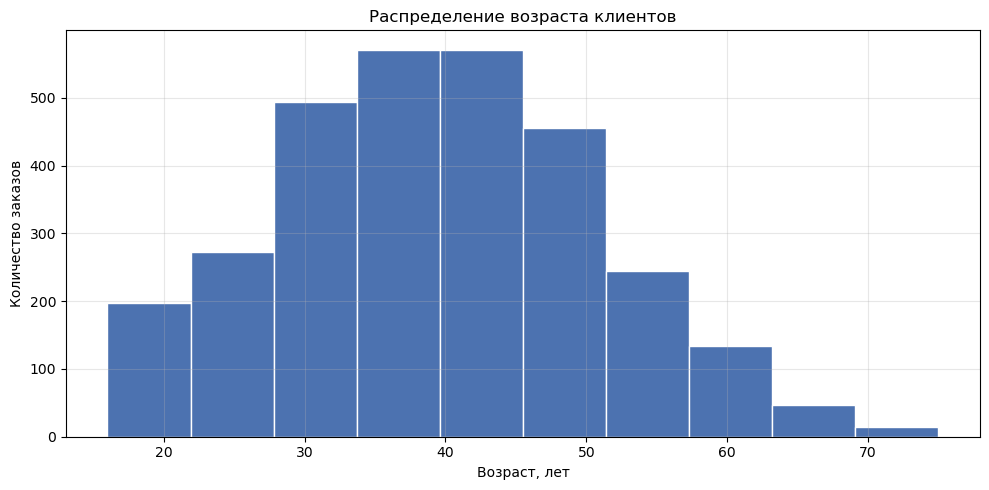

In [40]:
plt.hist(df["age"], bins=10, color="#4C72B0", edgecolor="white")
plt.title("Распределение возраста клиентов")
plt.xlabel("Возраст, лет")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

**Вывод:** распределение возраста близко к нормальному: максимум приходится на
интервал 34–46 лет (570 и 571 заказ в двух соседних интервалах), а к краям
диапазона число заказов убывает — 197 заказов в группе 16–22 года и всего
15 заказов в группе 69–75 лет. Разброс от 16 до 75 лет говорит о достаточно
широкой аудитории магазина.

### Задание 2. Распределение выручки

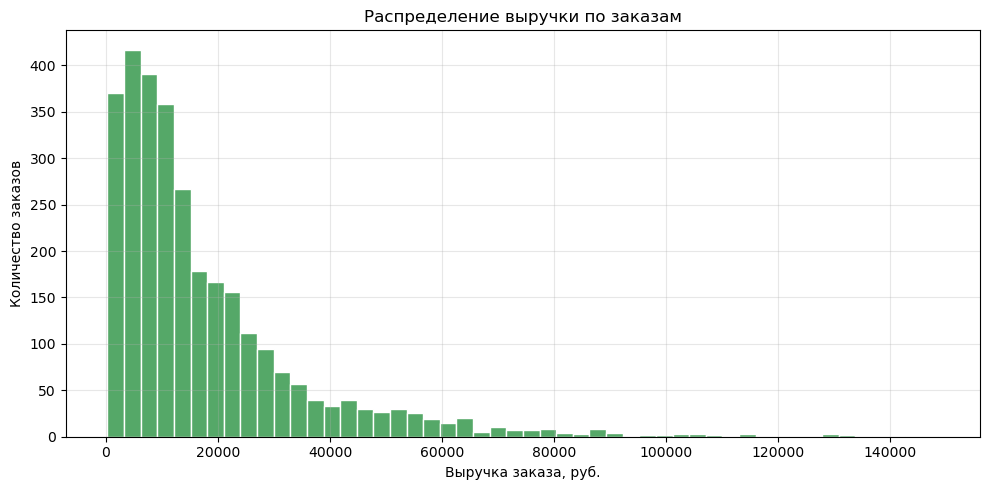

In [41]:
plt.hist(df["revenue"], bins=50, color="#55A868", edgecolor="white")
plt.title("Распределение выручки по заказам")
plt.xlabel("Выручка заказа, руб.")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

**Вывод:** распределение выручки сильно асимметрично (правостороннее) — 60 %
заказов дают выручку до 15 000 руб., а длинный «хвост» из редких дорогих
заказов уходит к 148 618 руб. Из-за этого среднее значение (17 817 руб.)
на 51 % больше медианного (11 775 руб.), и для описания типичного заказа
корректнее использовать медиану.

### Задание 3. Распределение скидки

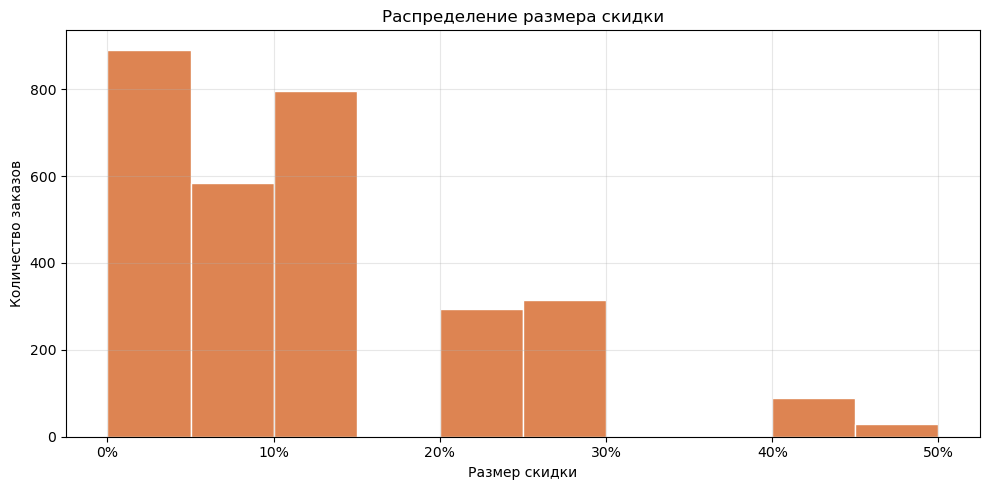

In [42]:
plt.hist(df["discount"], bins=10, color="#DD8452", edgecolor="white")
plt.title("Распределение размера скидки")
plt.xlabel("Размер скидки")
plt.ylabel("Количество заказов")
plt.xticks(np.linspace(0, 0.5, 6), [f"{int(v * 100)}%" for v in np.linspace(0, 0.5, 6)])
plt.tight_layout()
plt.show()

**Вывод:** скидки небольшие и распределены неравномерно — 29,7 % заказов
реализованы вообще без скидки, а скидка 30 % и выше встречается лишь в 8,1 %
заказов. Такой профиль характерен для магазина, который не строит продажи
на массовых распродажах.

### Задание 4. Сравнение распределения возраста VIP и обычных клиентов

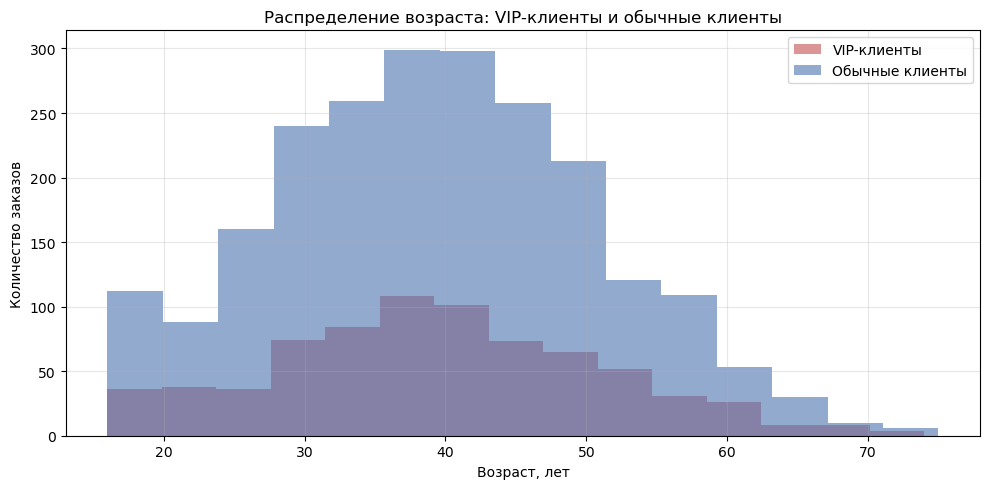

In [43]:
plt.hist(df.loc[df["is_vip"], "age"], bins=15, alpha=0.6,
         label="VIP-клиенты", color="#C44E52")
plt.hist(df.loc[~df["is_vip"], "age"], bins=15, alpha=0.6,
         label="Обычные клиенты", color="#4C72B0")
plt.title("Распределение возраста: VIP-клиенты и обычные клиенты")
plt.xlabel("Возраст, лет")
plt.ylabel("Количество заказов")
plt.legend()
plt.tight_layout()
plt.show()

**Вывод:** форма распределений практически одинакова — VIP-клиенты не
концентрируются в каком-то отдельном возрастном сегменте, а лишь составляют
ровную долю (24,8 %) во всех группах. Значит, в этих данных возраст не является
признаком, отличающим VIP-аудиторию.

### Задание 5. Выручка по категориям

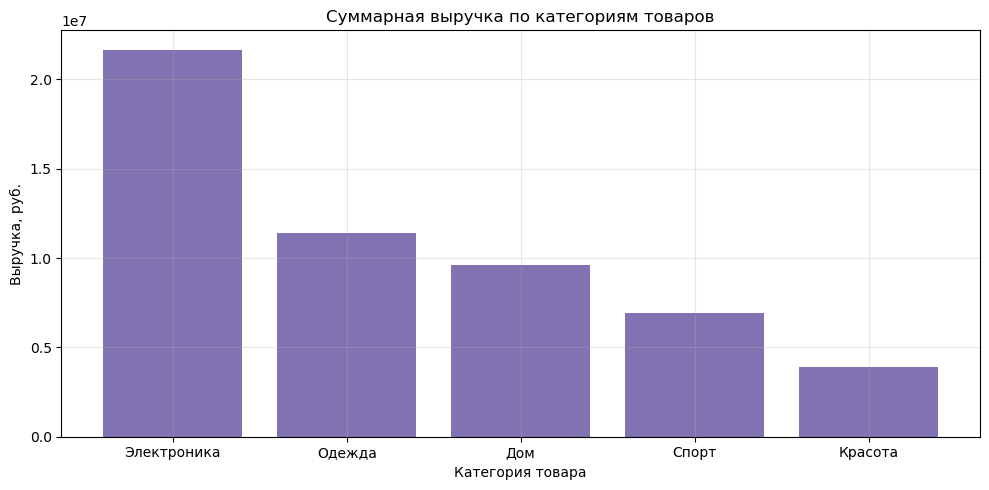

In [44]:
revenue_by_category = df.groupby("category")["revenue"].sum().sort_values(ascending=False)
plt.bar(revenue_by_category.index, revenue_by_category.values, color="#8172B2")
plt.title("Суммарная выручка по категориям товаров")
plt.xlabel("Категория товара")
plt.ylabel("Выручка, руб.")
plt.tight_layout()
plt.show()

**Вывод:** столбчатая диаграмма наглядно показывает сильное неравенство вкладов
категорий: «Электроника» (21,7 млн руб.) даёт больше выручки, чем две следующие
категории вместе взятые («Одежда» + «Дом» = 21,0 млн руб.), а «Красота»
замыкает список с результатом 3,9 млн руб.

### Задание 6. Количество заказов по городам

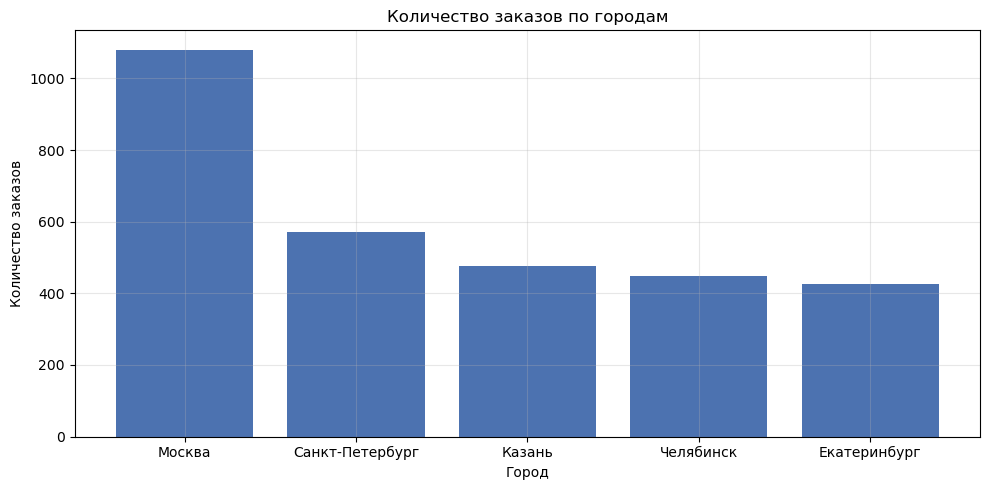

In [45]:
orders_by_city = df["city"].value_counts()
plt.bar(orders_by_city.index, orders_by_city.values, color="#4C72B0")
plt.title("Количество заказов по городам")
plt.xlabel("Город")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

**Вывод:** распределение заказов по городам повторяет структуру населения —
36,0 % заказов приходится на Москву (1080 заказов), 19,0 % — на Санкт-Петербург
(570), а остальные три города дают примерно по 14–16 % каждый.

### Задание 7. Количество заказов по возрастным группам

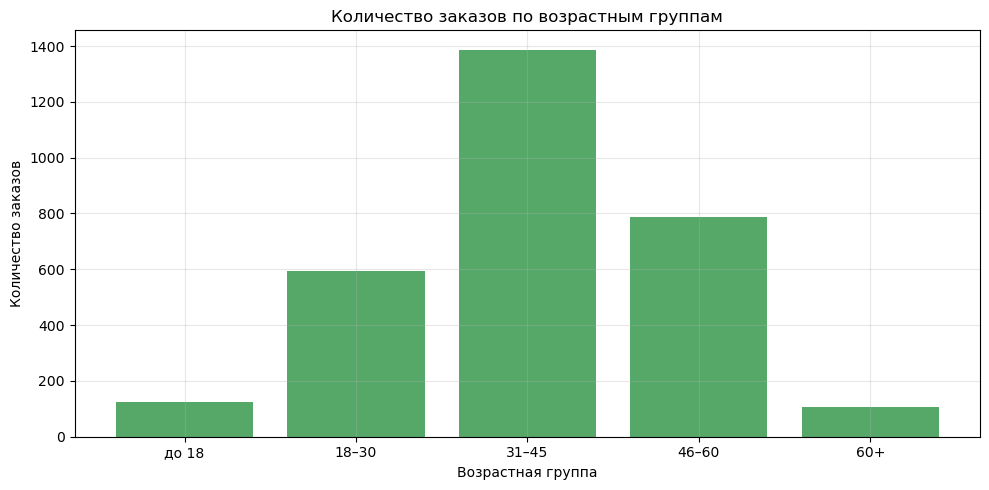

In [46]:
age_group_orders = df["age_group"].value_counts().reindex(labels, fill_value=0)
plt.bar(range(len(labels)), age_group_orders.values, color="#55A868")
plt.xticks(range(len(labels)), labels)
plt.title("Количество заказов по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

**Вывод:** ядро аудитории — клиенты 31–45 лет (1387 заказов, 46,2 %),
на втором месте группа 46–60 лет (787 заказов, 26,2 %). Клиенты моложе
30 лет формируют 23,9 % заказов, а покупатели старше 60 лет — всего 3,6 %,
что типично для магазина дорогих товаров.

### Задание 8. Количество заказов по статусам

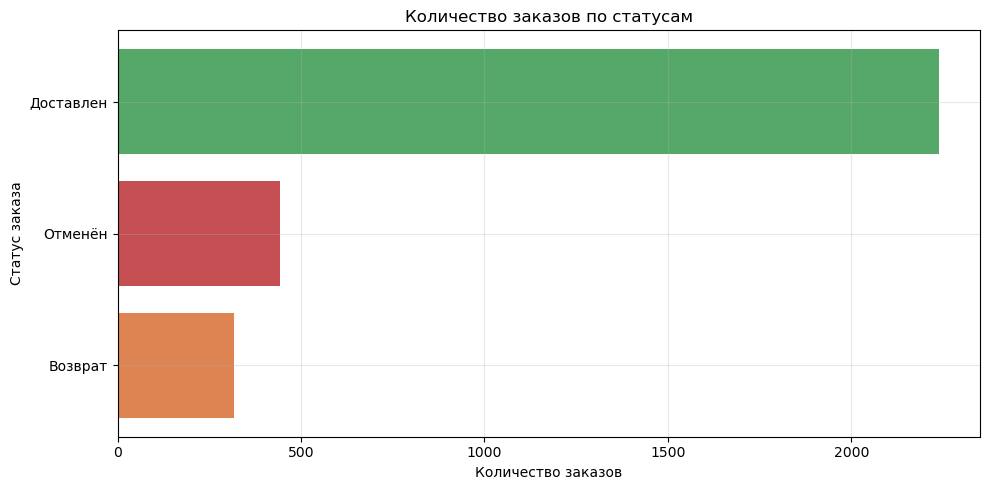

In [47]:
status_counts = df["status"].value_counts().sort_values()
plt.barh(status_counts.index, status_counts.values,
         color=["#DD8452", "#C44E52", "#55A868"])
plt.title("Количество заказов по статусам")
plt.xlabel("Количество заказов")
plt.ylabel("Статус заказа")
plt.tight_layout()
plt.show()

**Вывод:** статусы распределены следующим образом: «Доставлен» — 2239 заказов
(74,6 %), «Отменён» — 443 (14,8 %), «Возврат» — 318 (10,6 %). Доля нереализованных
заказов (25,4 %) довольно высока и должна учитываться при планировании выручки.

### Задание 9. Выручка по месяцам

2024-01    3609084.57
2024-02    4391295.15
2024-03    4772227.95
2024-04    4490022.64
2024-05    4060377.45
2024-06    4437174.04
2024-07    4880847.32
2024-08    4246840.33
2024-09    5097596.38
2024-10    4108089.43
2024-11    4518666.74
2024-12    4839566.57
Name: revenue, dtype: float64


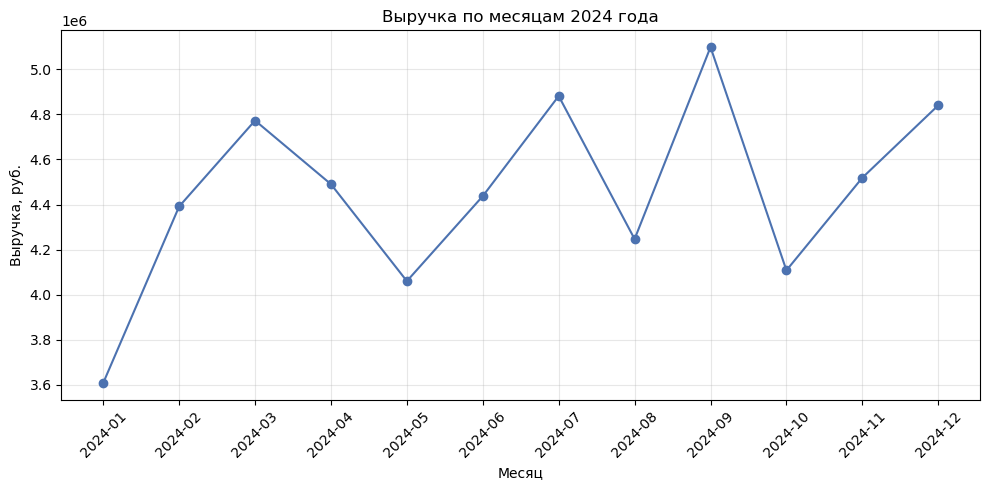

In [48]:
monthly = df.groupby(["year", "month"])["revenue"].sum()
monthly.index = [f"{year}-{month:02d}" for year, month in monthly.index]

print(monthly.round(2))

plt.plot(monthly.index, monthly.values, marker="o", color="#4C72B0")
plt.title("Выручка по месяцам 2024 года")
plt.xlabel("Месяц")
plt.ylabel("Выручка, руб.")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Вывод по графику:** выручка колеблется в пределах от 3,61 млн руб. (январь)
до 5,10 млн руб. (сентябрь) — разброс от −19 % до +14 % относительно среднего
(4,45 млн руб.). Максимумы приходятся на сентябрь, июль и декабрь, а минимумы —
на январь, май и октябрь, поэтому устойчивого тренда и выраженной сезонности
не наблюдается: ни роста, ни падения продаж за год не зафиксировано. Это
ожидаемо, поскольку даты заказов были сгенерированы равномерно по всему году.

## Часть 6. Мини-анализ

Ниже — несколько обобщающих расчётов и краткие выводы по ним.

### Задание 1. Общая статистика

In [49]:
total_orders = df.shape[0]
total_revenue = df["revenue"].sum()
avg_revenue = df["revenue"].mean()
real_revenue = df.loc[df["is_real_sale"], "revenue"].sum()

print("Общее количество заказов:", total_orders)
print("Общая выручка, руб.:", round(total_revenue, 2))
print("Средняя выручка заказа, руб.:", round(avg_revenue, 2))
print("Медианная выручка заказа, руб.:", round(df["revenue"].median(), 2))
print("Выручка доставленных заказов, руб.:", round(real_revenue, 2))
print("Средняя выручка доставленного заказа, руб.:",
      round(df.loc[df["is_real_sale"], "revenue"].mean(), 2))

Общее количество заказов: 3000
Общая выручка, руб.: 53451788.56
Средняя выручка заказа, руб.: 17817.26
Медианная выручка заказа, руб.: 11774.71
Выручка доставленных заказов, руб.: 39350490.37
Средняя выручка доставленного заказа, руб.: 17575.03


**Вывод:** за год магазин обработал 3000 заказов на общую сумму 53,45 млн руб.,
средний чек — 17 817 руб., медиана — 11 775 руб. Медиана на 34 % ниже среднего,
что подтверждает перекос распределения в сторону небольших заказов; при этом
фактически реализовано только 39,35 млн руб. (73,6 % расчётной выручки).

### Задание 2. Категории с максимальной и минимальной выручкой

In [50]:
category_revenue = df.groupby("category")["revenue"].sum().sort_values(ascending=False)

print("Выручка по категориям, руб.:")
print(category_revenue.round(2))
print()
print("Максимальная выручка:", category_revenue.idxmax(),
      "—", round(category_revenue.max(), 2), "руб.")
print("Минимальная выручка:", category_revenue.idxmin(),
      "—", round(category_revenue.min(), 2), "руб.")
print("Во сколько раз больше:", round(category_revenue.max() / category_revenue.min(), 1))
print("Доля лидера в общей выручке, %:", round(category_revenue.max() / total_revenue * 100, 1))

Выручка по категориям, руб.:
category
Электроника    21663043.51
Одежда         11409866.43
Дом             9600474.56
Спорт           6900202.90
Красота         3878201.17
Name: revenue, dtype: float64

Максимальная выручка: Электроника — 21663043.51 руб.
Минимальная выручка: Красота — 3878201.17 руб.
Во сколько раз больше: 5.6
Доля лидера в общей выручке, %: 40.5


**Вывод:** максимум даёт категория **«Электроника»** (21,66 млн руб., 40,5 %
выручки), минимум — **«Красота»** (3,88 млн руб., 7,3 %). Разница в 5,6 раза
объясняется разницей в среднем чеке, а не количеством заказов
(705 против 479): экономика магазина определяется структурой продаж
электроники.

### Задание 3. Доля выручки VIP-заказов

In [51]:
vip_revenue = df.loc[df["is_vip"], "revenue"].sum()
total_revenue = df["revenue"].sum()
vip_share = vip_revenue / total_revenue

print("Выручка VIP-заказов, руб.:", round(vip_revenue, 2))
print("Общая выручка, руб.:", round(total_revenue, 2))
print("Доля выручки VIP-заказов: {:.1%}".format(vip_share))
print()
print("Доля VIP-заказов в общем числе заказов: {:.1%}".format(df["is_vip"].mean()))
print("Средний чек VIP, руб.:", round(df.loc[df["is_vip"], "revenue"].mean(), 2))
print("Средний чек обычных клиентов, руб.:", round(df.loc[~df["is_vip"], "revenue"].mean(), 2))

Выручка VIP-заказов, руб.: 13423481.12
Общая выручка, руб.: 53451788.56
Доля выручки VIP-заказов: 25.1%

Доля VIP-заказов в общем числе заказов: 24.8%
Средний чек VIP, руб.: 18042.31
Средний чек обычных клиентов, руб.: 17743.04


**Вывод:** VIP-заказы дают **25,1 % выручки** (13,42 млн руб. из 53,45 млн),
что практически совпадает с долей VIP-заказов в общем их количестве (24,8 %).
Средний чек VIP-клиента (18 042 руб.) и обычного клиента (17 743 руб.) отличается
всего на 1,7 % — в этих данных статус VIP увеличивает не размер заказа, а только
его количество, поэтому прямой экономический эффект от VIP-статуса ограничен:
без скидок и условий для VIP-клиентов он почти не окупается.

### Задание 4. Влияние размера скидки на выручку

Разобьём скидку на интервалы и посчитаем по каждому среднюю выручку заказа,
среднюю выручку с одной единицы товара, среднее количество товаров, среднюю
прибыль и долю группы в общей выручке. Интервалы `pd.cut()` по умолчанию
закрыты справа, поэтому скидка 10 % попадает в группу «до 10 %», 20 % — в «10–20 %»
и так далее; в последней группе «30–50 %» фактически оказываются скидки 40 % и 50 %.

In [52]:
df["revenue_per_unit"] = df["revenue"] / df["quantity"]

discount_bins = [-0.001, 0.0, 0.10, 0.20, 0.30, 0.51]
discount_labels = ["без скидки", "до 10%", "10–20%", "20–30%", "30–50%"]
df["discount_group"] = pd.cut(df["discount"], bins=discount_bins, labels=discount_labels)

discount_stats = df.groupby("discount_group", observed=True).agg(
    orders=("order_id", "count"),
    avg_quantity=("quantity", "mean"),
    avg_revenue=("revenue", "mean"),
    avg_revenue_per_unit=("revenue_per_unit", "mean"),
    avg_profit=("profit", "mean"),
    revenue=("revenue", "sum"),
)
discount_stats["revenue_share_%"] = discount_stats["revenue"] / total_revenue * 100
print(discount_stats.round(2))

                orders  avg_quantity  avg_revenue  avg_revenue_per_unit  \
discount_group                                                            
без скидки         891          2.12     19717.16               9069.22   
до 10%            1066          2.18     18843.54               8572.13   
10–20%             609          2.21     15805.50               7225.57   
20–30%             315          2.20     14855.92               6669.19   
30–50%             119          2.17     12532.89               5874.95   

                avg_profit      revenue  revenue_share_%  
discount_group                                            
без скидки        13116.66  17567993.78            32.87  
до 10%            12162.29  20087214.34            37.58  
10–20%             9456.57   9625550.06            18.01  
20–30%             8279.54   4679616.23             8.75  
30–50%             5097.91   1491414.15             2.79  


**Вывод:** с ростом скидки выручка падает монотонно. Средняя выручка заказа
снижается с 19 717 руб. без скидки до 12 533 руб. в группе «30–50 %» (минус 36 %),
а средняя выручка с одной единицы товара — с 9 069 руб. до 5 875 руб. (минус 35 %).
Сильнее всего страдает прибыль: с 13 117 руб. до 5 098 руб., то есть минус 61 %,
поэтому скидка бьёт прежде всего по марже. При этом среднее количество товаров
в заказе практически не меняется (2,12–2,21 единицы), то есть скидки не стимулируют
объём покупки, а работают как прямая потеря выручки: на заказы со скидкой 40–50 %
приходится всего 2,8 % выручки при 4 % заказов.

### Задание 5. Возвраты и отмены по категориям

In [53]:
not_delivered = df.loc[~df["is_real_sale"]]

print("Отменённых и возвращённых заказов:", len(not_delivered),
      "({:.1f} %)".format(len(not_delivered) / len(df) * 100))
print()
print("Количество по статусам:")
print(df["status"].value_counts().loc[["Отменён", "Возврат"]])
print()

# Таблица «категория × статус» только для нереализованных заказов
bad_by_category = pd.crosstab(not_delivered["category"], not_delivered["status"])
bad_by_category["Итого"] = bad_by_category.sum(axis=1)
bad_by_category = bad_by_category.sort_values("Итого", ascending=False)
print("Нереализованные заказы по категориям:")
print(bad_by_category)
print()

# Доля нереализованных заказов внутри каждой категории
share_in_category = (
    bad_by_category["Итого"] / df["category"].value_counts() * 100
).sort_values(ascending=False)
print("Доля нереализованных заказов внутри категории, %:")
print(share_in_category.round(1))

Отменённых и возвращённых заказов: 761 (25.4 %)

Количество по статусам:
status
Отменён    443
Возврат    318
Name: count, dtype: int64

Нереализованные заказы по категориям:
status       Возврат  Отменён  Итого
category                            
Одежда            72      115    187
Электроника       67      108    175
Дом               74       77    151
Красота           52       76    128
Спорт             53       67    120

Доля нереализованных заказов внутри категории, %:
category
Красота        26.7
Спорт          26.3
Дом            25.2
Электроника    24.8
Одежда         24.6
dtype: float64


**Вывод:** всего не реализовано 761 заказ (25,4 %). В абсолютном выражении
больше всего их в категориях «Одежда» (187) и «Электроника» (175), но эти
категории просто имеют больше заказов. По доле внутри категории картина
выравнивается: от 24,6 % («Одежда») до 26,7 % («Красота»), разница составляет
всего 2,1 п. п. Практически это означает, что отмены и возвраты в данных
распределены равномерно по категориям и определяются общим уровнем сервиса,
а не спецификой товара.

## Часть 7. Итоговый вывод

Наиболее значимой категорией по выручке стала **«Электроника»**: 21,66 млн руб.
из 53,45 млн руб. общей выручки (40,5 %) при 23,5 % всех заказов, а вместе с
«Одеждой» (21,3 %) и «Домом» (18,0 %) три лидера формируют 79,8 % выручки
магазина. По городам безусловно доминирует **Москва** — 1080 заказов (36,0 %)
и 36,4 % выручки, почти вдвое больше Санкт-Петербурга (570 заказов),
в то время как Казань, Екатеринбург и Челябинск дают примерно равные объёмы
(425–477 заказов). **VIP-заказы обеспечивают 25,1 % выручки** при 24,8 % заказов,
и их средний чек (18 042 руб.) отличается от среднего чека обычных клиентов
(17 743 руб.) всего на 1,7 % — в этих данных VIP-статус увеличивает частоту
покупок, но не их стоимость, поэтому прямого финансового эффекта от него нет.
Особенность скидок в том, что они **равномерно снижают выручку**, а не увеличивают
объём: средняя выручка с одной единицы товара падает строго монотонно — с 9 069 руб.
без скидки до 5 875 руб. при скидке 40–50 % (минус 35 %), средняя прибыль — на 61 %,
а среднее количество товаров в заказе почти не меняется (2,12–2,21 единицы),
причём на заказы с глубокой скидкой приходится лишь 2,8 % выручки; кроме того,
все 240 заказов с отрицательной прибылью (8 % выборки) содержат ровно одну единицу
товара, что показывает: скидка опаснее всего на дорогих одиночных покупках.
**Категорий с аномально высоким уровнем возвратов нет**: доли нереализованных
заказов укладываются в узкий диапазон 24,6–26,7 %, а больше всего их в абсолютном
выражении у «Одежды» (187) и «Электроники» (175) только потому, что у этих
категорий больше заказов. Отдельно следует отметить, что около четверти заказов
(25,4 %) не реализуются вовсе, а учёт только доставленных заказов уменьшает выручку
с 53,45 до 39,35 млн руб. — поэтому показатель фактической выручки всегда нужно
считать по столбцу `is_real_sale`. Дополнительно стоило бы исследовать
**сезонность по месяцам** (в наших данных выручка колеблется от 3,61 млн
в январе до 5,10 млн в сентябре без явного тренда), влияние способа оплаты
и скидки на вероятность возврата, переход от себестоимости единицы товара к затратам
на весь заказ, а также повторные покупки и возвращаемость клиентов (`customer_id`).

## Часть 8. Оформление работы и Git

Ноутбук оформлен в соответствии с требованиями:

* использованы Markdown-заголовки для всех частей и заданий;
* задания разделены по смыслу, сложные блоки кода снабжены пояснениями;
* после каждого расчёта приведён результат и краткий вывод;
* неиспользуемый код отсутствует, все переменные используются дальше по ноутбуку.

Рекомендуемая история коммитов (репозиторий инициализируется вручную):

```bash
git init
git add .
git commit -m "Добавлена генерация и подготовка данных интернет-магазина"
git commit -m "Добавлены фильтрация, группировка и визуализация"
git commit -m "Добавлен мини-анализ и итоговые выводы"
```

Файл`README.md` с полями **ФИО** и **Группа** оформляется отдельно.
Ответы на контрольные вопросы (часть 10 задания) вынесены в отдельный файл
`контрольные_вопросы лб2 (ч2).txt`.